# Bank Loan analysis Report

## Import libraries


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings as wrg
import plotly.express as px

In [2]:
df=pd.read_excel(r"C:\Users\haree\OneDrive\Desktop\HARESSH_work\python_vs_code\my_project\Python Project - Finance Domain-20260523T175326Z-3-001\financial_loan.xlsx")

In [3]:
df.head(3)

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522


In [4]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [5]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

## Metadata of data

In [6]:
print(f"Columns:{df.shape[1]}")
print(f"Rows:{df.shape[0]}")

Columns:24
Rows:38576


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

### Data types

In [8]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

### Total loan application

In [9]:
total_loan_application=df['id'].count()
print("total loan application",total_loan_application)

total loan application 38576


### MTD Toatal Loan Application

In [10]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month= latest_issue_date.month

mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_loan_application=mtd_data['id'].count()

print(f" MTD loan application (for {latest_issue_date.strftime('%B %Y')}): {mtd_loan_application}")

 MTD loan application (for December 2021): 4314


### Total Funded Amount

In [11]:
total_funded_amount= df['loan_amount'].sum()
total_funded_amount_million= total_funded_amount/1000000
print(f"Total Amoutn Funded ${total_funded_amount_million:0.2f}M")

Total Amoutn Funded $435.76M


### MTD Total Funded Amount

In [12]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month= latest_issue_date.month

mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_funded_amount=mtd_data['loan_amount'].sum()

mtd_total_funded_amount_million=mtd_total_funded_amount/1000000

print(f" MTD total funded amount (for {latest_issue_date.strftime('%B %Y')}): ${mtd_total_funded_amount_million:0.2f}M")

 MTD total funded amount (for December 2021): $53.98M


### Total Amount Reciewved


In [13]:
total_received_amount= df['total_payment'].sum()
total_received_amount_million= total_received_amount/1000000
print(f"Total Amount Received ${total_received_amount_million:0.2f}M")

Total Amount Received $473.07M


### MTD Total Amount Received

In [14]:
latest_issue_date=df['issue_date'].max()
latest_year=latest_issue_date.year
latest_month= latest_issue_date.month

mtd_data=df[(df['issue_date'].dt.year==latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_received_amount=mtd_data['total_payment'].sum()

mtd_total_received_amount_million=mtd_total_received_amount/1000000

print(f" MTD total Received amount (for {latest_issue_date.strftime('%B %Y')}): ${mtd_total_received_amount_million:0.2f}M")

 MTD total Received amount (for December 2021): $58.07M


### Avg Intrest Rate


In [15]:
avg_intrest_rate=df['int_rate'].mean() *100
print(f" Average Intrest Rate in Percetage {avg_intrest_rate:0.2f}%")

 Average Intrest Rate in Percetage 12.05%


### Average Debt to income ratio

In [16]:
avg_dti=df['dti'].mean() *100
print(f" Average Debt to income ratio: {avg_dti:0.2f}%")

 Average Debt to income ratio: 13.33%


### Good Loan Matrics


In [17]:
good_loans=df[df['loan_status'].isin(['Fully Paid', 'Current'])]

total_loan_application = df['id'].count()

number_of_good_loans=good_loans['id'].count()

good_loan_funded_amount=good_loans['loan_amount'].sum()

good_loan_received=good_loans['total_payment'].sum()

good_loan_funded_amount_million=good_loan_funded_amount/1000000

good_loan_received_million=good_loan_received/1000000

good_loan_percentage=(number_of_good_loans/total_loan_application)*100



print(f"Number of good laon sanctioned:{number_of_good_loans}")

print(f"Good Loan Funded amount: ${good_loan_funded_amount_million:0.2f}M")

print(f"Good loan received amount: ${good_loan_received_million:0.2f}M")

print(f"Good loans percentage: {good_loan_percentage:0.2f}%")

Number of good laon sanctioned:33243
Good Loan Funded amount: $370.22M
Good loan received amount: $435.79M
Good loans percentage: 86.18%


In [18]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')

### Bad Loans

In [19]:
bad_loans=df[df['loan_status'].isin(['Charged Off'])]

total_loan_application = df['id'].count()

number_of_bad_loans=bad_loans['id'].count()

bad_loan_funded_amount=bad_loans['loan_amount'].sum()

bad_loan_received=bad_loans['total_payment'].sum()

bad_loan_funded_amount_million=bad_loan_funded_amount/1000000

bad_loan_received_million=bad_loan_received/1000000

bad_loan_percentage=(number_of_bad_loans/total_loan_application)*100



print(f"Number of good laon sanctioned:{number_of_bad_loans}")

print(f"Bad Loan Funded amount: ${bad_loan_funded_amount_million:0.2f}M")

print(f"Bad loan received amount: ${bad_loan_received_million:0.2f}M")

print(f"Bad loans percentage: {bad_loan_percentage:0.2f}%")

Number of good laon sanctioned:5333
Bad Loan Funded amount: $65.53M
Bad loan received amount: $37.28M
Bad loans percentage: 13.82%


In [20]:
df['loan_status'].unique()

array(['Charged Off', 'Fully Paid', 'Current'], dtype=object)

### Monthly Trends issue date for Total funded amount

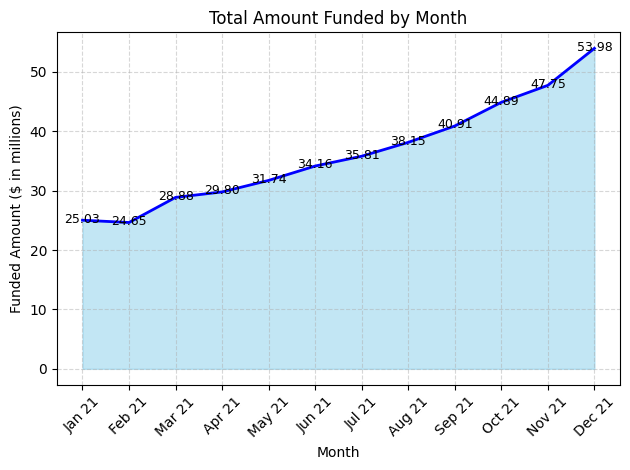

In [21]:
monthly_funded=(
    df.sort_values('issue_date')
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %y'))
    .groupby('month_name',sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_million')       
)



plt.Figure(figsize=(12,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_million'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_million'],color='blue',lw=2)
for i, row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_million']+0.2,f"{row['loan_amount_million']:.2f}",
             ha='center',va='center',fontsize=9,rotation=0,color='black')

plt.title("Total Amount Funded by Month")
plt.xlabel('Month')
plt.ylabel('Funded Amount ($ in millions)')
plt.xticks(ticks=range(len(monthly_funded)),labels=monthly_funded['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()


In [22]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


### Monthly Trends by Issue Date for Total Amomunt Received

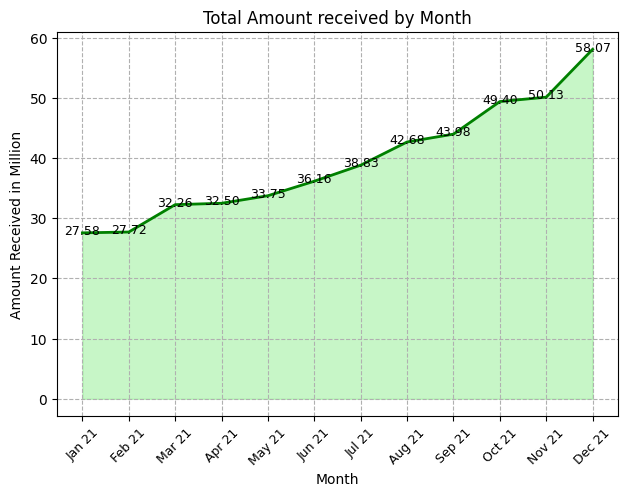

In [23]:
monthly_received=(df.sort_values('issue_date')
                  .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %y'))
                  .groupby('month_name',sort=False)['total_payment']
                  .sum()
                  .div(1000000)  
                  .reset_index(name='received_amount_million')                
                  )

plt.Figure(figsize=(10,7))
plt.fill_between(monthly_received['month_name'],monthly_received['received_amount_million'],color='lightgreen',alpha=0.5)
plt.plot(monthly_received['month_name'],monthly_received['received_amount_million'],color='green',lw=2)

for i, row in monthly_received.iterrows():
    plt.text(i,row['received_amount_million']+0.3,f"{row['received_amount_million']:0.2f}",
             ha='center',va='center',fontsize=9)
plt.xlabel('Month')
plt.ylabel('Amount Received in Million')
plt.title('Total Amount received by Month')
plt.tight_layout()
plt.grid(True,linestyle='--')
plt.xticks(ticks=range(len(monthly_received)),labels=monthly_received['month_name'],fontsize=9,rotation=45,color='black')
plt.show()

### Monthly Trends by Issue Date for Total Loan Applications

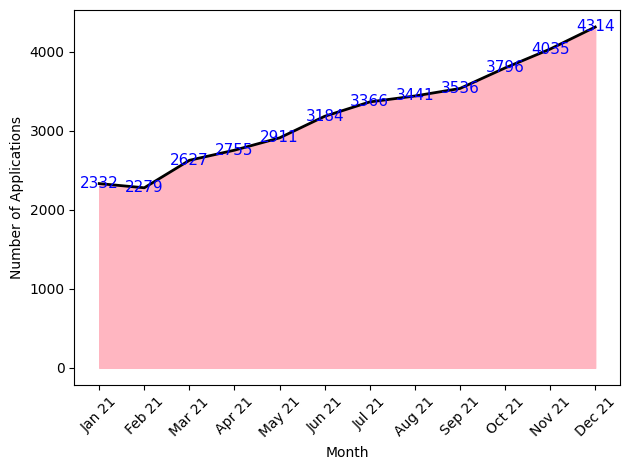

In [24]:
monthly_applications=(df.sort_values('issue_date')
                      .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b %y'))
                      .groupby('month_name',sort=False)['id']
                      .count()
                      .reset_index(name='Number_of_applications')
)


plt.Figure(figsize=(10,5))
plt.fill_between(monthly_applications['month_name'],monthly_applications['Number_of_applications'],color='lightpink')
plt.plot(monthly_applications['month_name'],monthly_applications['Number_of_applications'],color='black',lw=2)
for i,rows in monthly_applications.iterrows():
    plt.text(i,rows['Number_of_applications']+0.5,f"{rows['Number_of_applications']}",
             ha='center',va='center',fontsize=11,color='blue')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.xticks(range(len(monthly_applications)),labels=monthly_applications['month_name'],rotation=45)
plt.tight_layout()
plt.show()

### Regional Analysis by state for Total funded amount

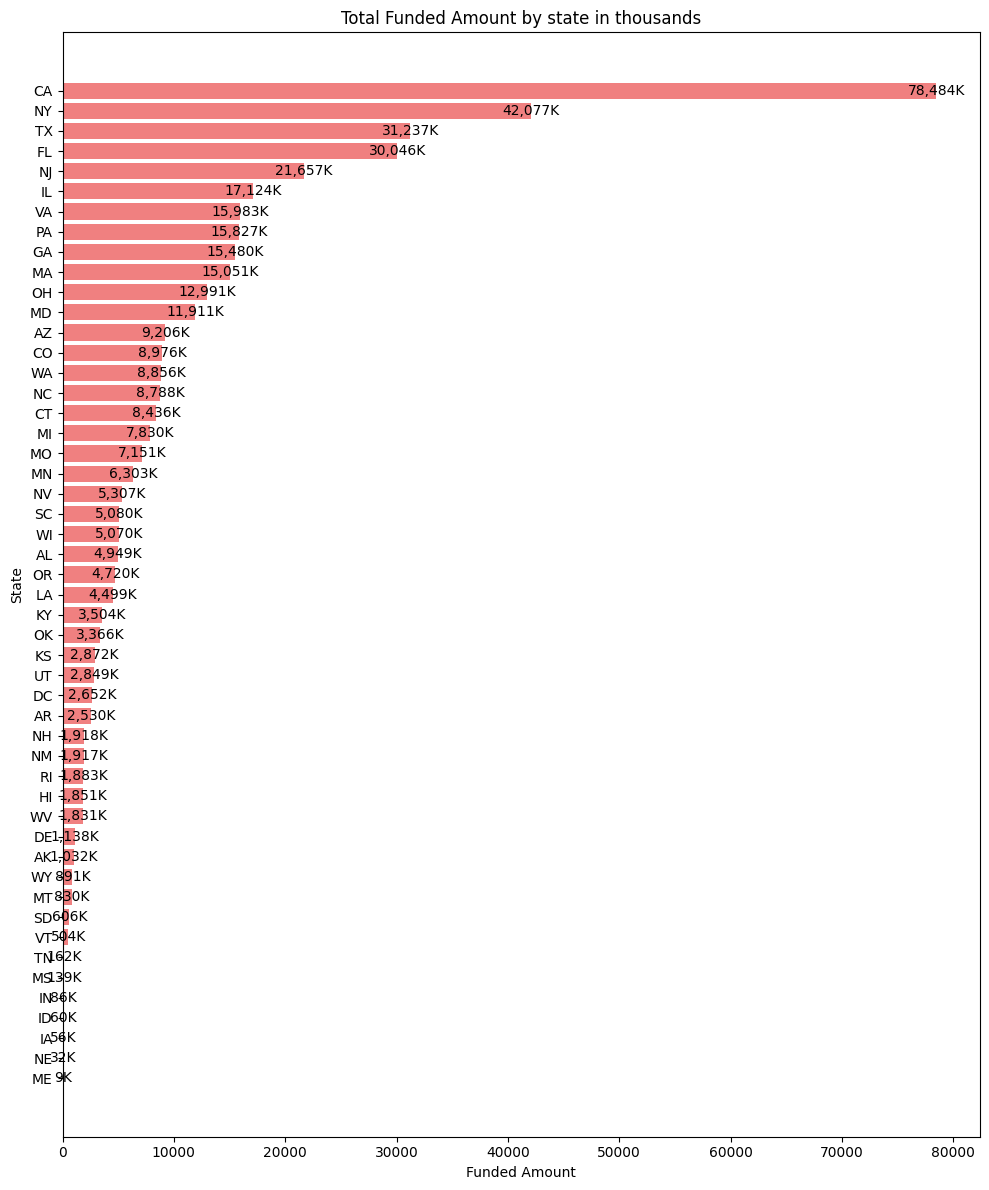

In [25]:
state_fund=df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_fund_in_thousands=state_fund/1000

plt.figure(figsize=(10,12))
bars=plt.barh(state_fund_in_thousands.index,state_fund_in_thousands.values,color='lightcoral')

for bar in bars:
    width=bar.get_width()
    plt.text(width+10,bar.get_y()+bar.get_height()/2,
             f"{width:,.0f}K",va='center',ha='center')
    


plt.title("Total Funded Amount by state in thousands")
plt.xlabel("Funded Amount")
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by state for Total Received amount

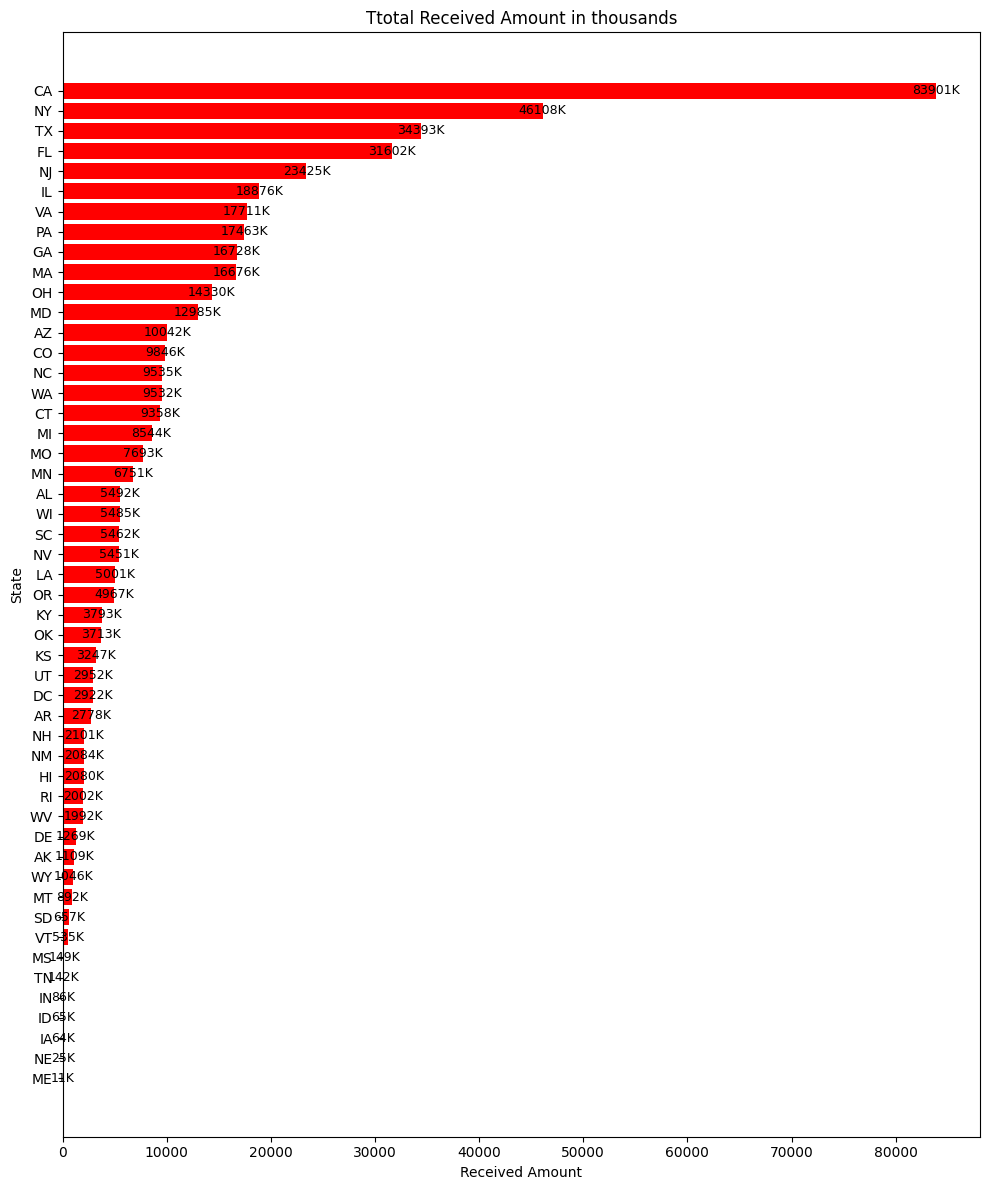

In [26]:
state_received= df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)
state_received_Thousands=state_received/1000



plt.figure(figsize=(10,12))
barh=plt.barh(state_received_Thousands.index,state_received_Thousands.values,color='red')

for bar in barh:
    width=bar.get_width()
    plt.text(width,bar.get_y()+bar.get_height()/2,
             f"{width:0.0f}K",va='center',ha='center',fontsize=9)
    

plt.title('Ttotal Received Amount in thousands')
plt.xlabel("Received Amount")
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Regional Analysis by state for Total application received

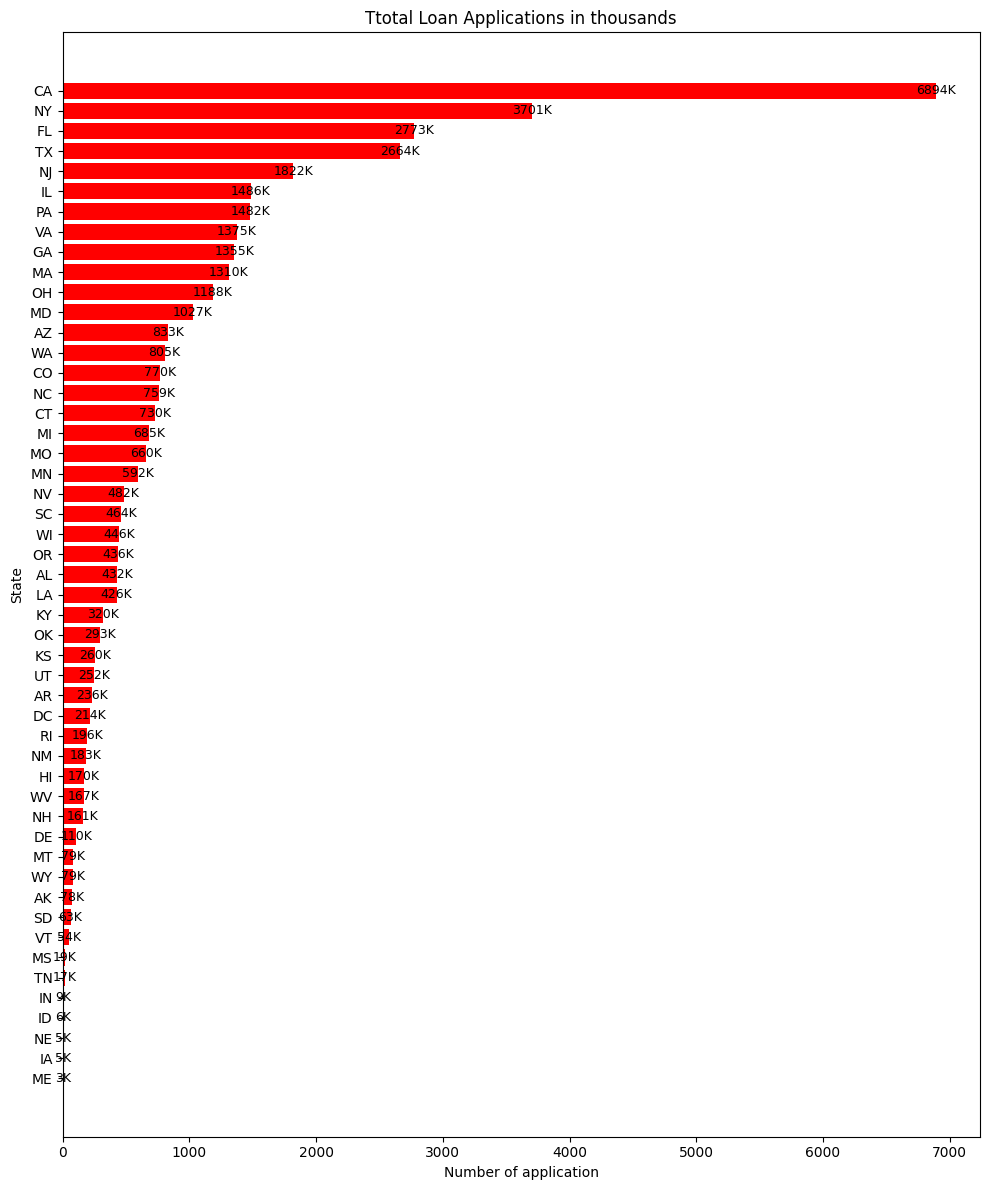

In [27]:
number_of_application= df.groupby('address_state')['id'].count().sort_values(ascending=True)


plt.figure(figsize=(10,12))
barh=plt.barh(number_of_application.index,number_of_application.values,color='red')

for bar in barh:
    width=bar.get_width()
    plt.text(width,bar.get_y()+bar.get_height()/2,
             f"{width:0.0f}K",va='center',ha='center',fontsize=9)
    

plt.title('Ttotal Loan Applications in thousands')
plt.xlabel("Number of application")
plt.ylabel('State')
plt.tight_layout()
plt.show()

### Long term analysis by total funded amount

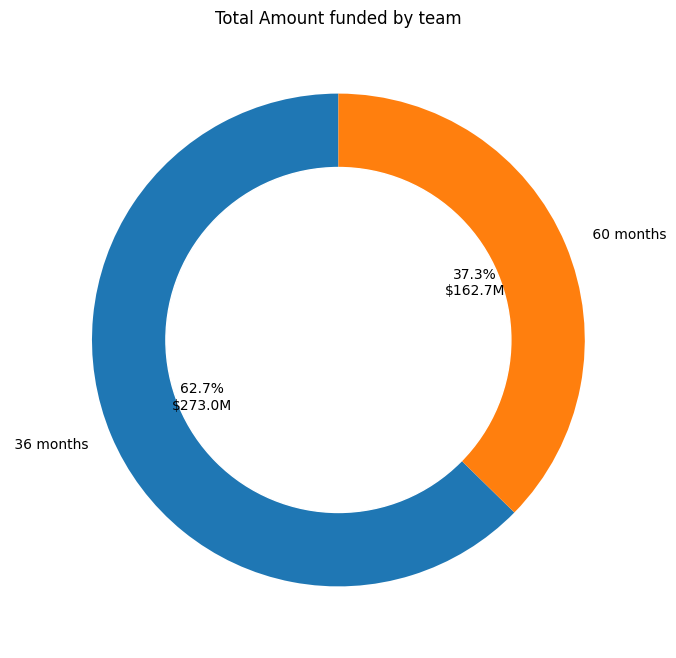

In [28]:
term_fund_millions=df.groupby('term')['loan_amount'].sum()/1000000

plt.figure(figsize=(10,8))
plt.pie(
    term_fund_millions,
    labels=term_fund_millions.index,
    autopct=lambda p:f"{p:0.1f}%\n${p*sum(term_fund_millions)/100:.1f}M"
    ,startangle=90
    ,wedgeprops={'width':.4}
)


plt.gca().add_artist(plt.Circle((0,0),.7,color='white'))
plt.title("Total Amount funded by team")
plt.show()

### Long term analysis by total Received amount

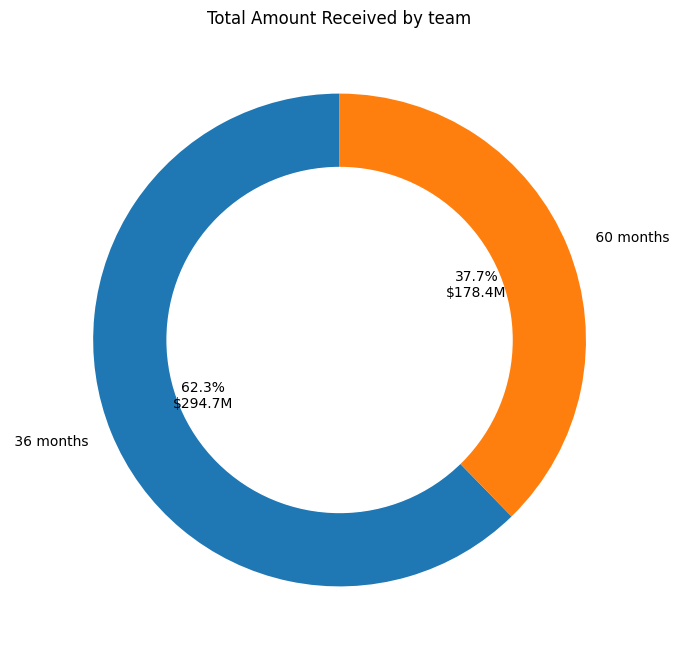

In [29]:
term_received_millions=df.groupby('term')['total_payment'].sum()/1000000

plt.figure(figsize=(10,8))
plt.pie(
    term_received_millions,
    labels=term_received_millions.index,
    autopct=lambda p:f"{p:0.1f}%\n${p*sum(term_received_millions)/100:.1f}M"
    ,startangle=90
    ,wedgeprops={'width':.4}
)


plt.gca().add_artist(plt.Circle((0,0),.7,color='white'))
plt.title("Total Amount Received by team")
plt.show()

### Long term analysis by total number of applications

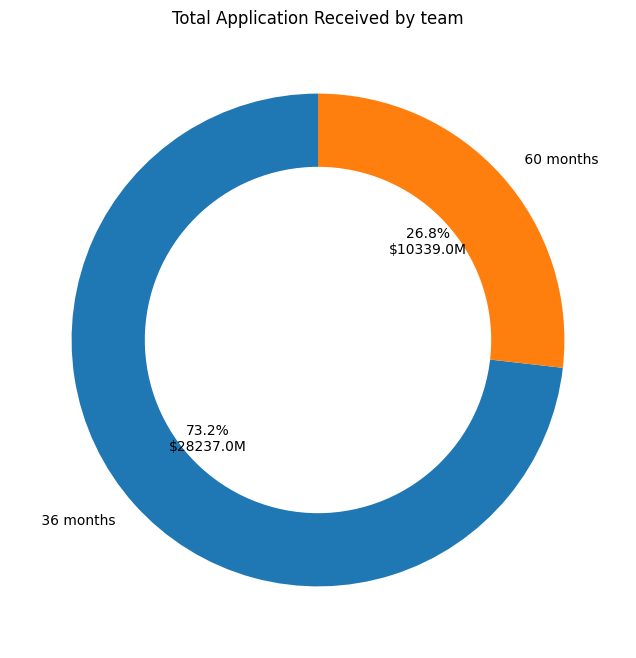

In [30]:
number_of_applications=df.groupby('term')['id'].count()

plt.figure(figsize=(10,8))
plt.pie(
    number_of_applications,
    labels=number_of_applications.index,
    autopct=lambda p:f"{p:0.1f}%\n${p*sum(number_of_applications)/100:.1f}M"
    ,startangle=90
    ,wedgeprops={'width':.4}
)


plt.gca().add_artist(plt.Circle((0,0),.7,color='white'))
plt.title("Total Application Received by team")
plt.show()

### Emplyoee Length by Total funded amount

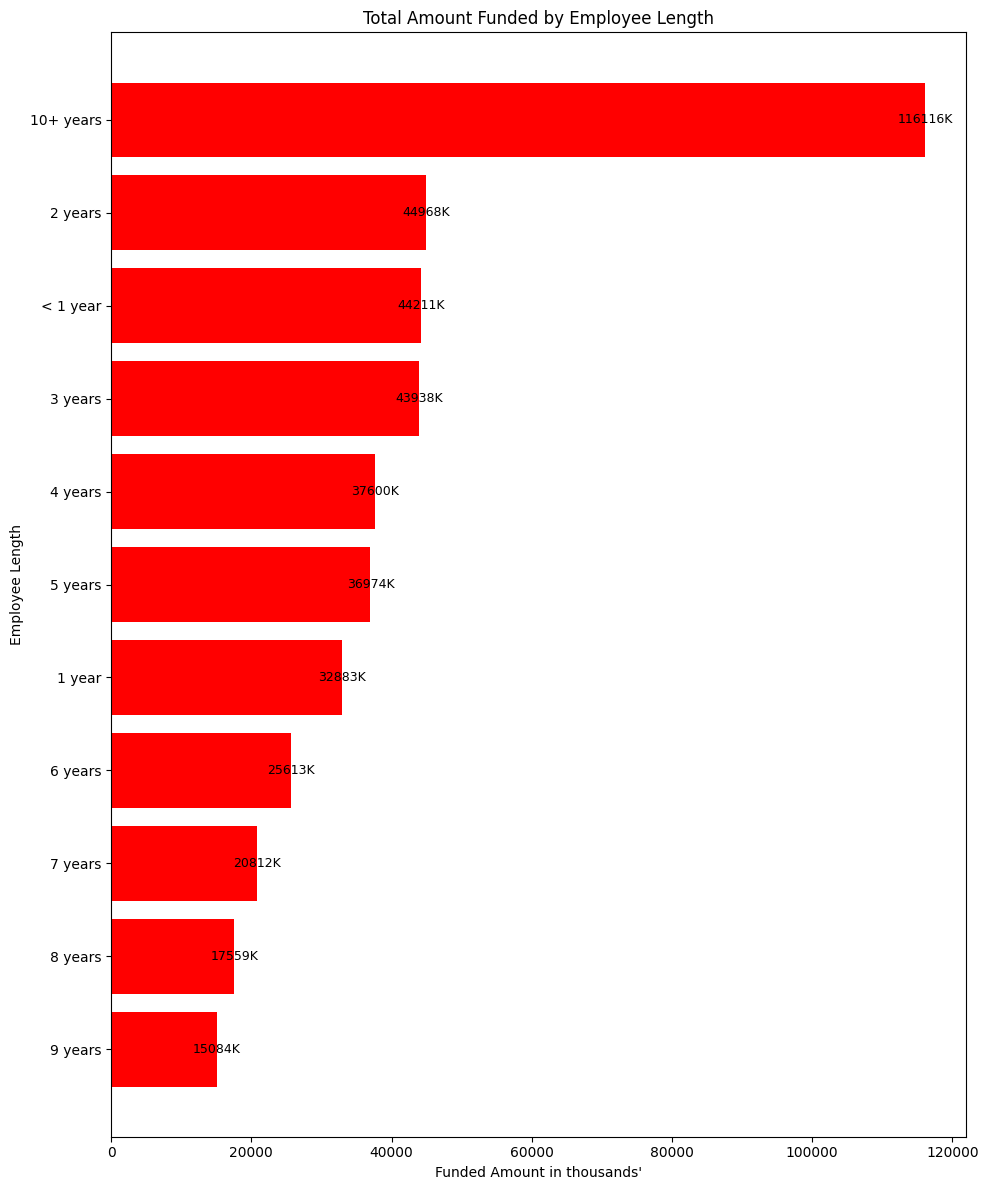

In [31]:
emp_fund= df.groupby('emp_length')['loan_amount'].sum().sort_values(ascending=True)/1000


plt.figure(figsize=(10,12))
barh=plt.barh(emp_fund.index,emp_fund.values,color='red')

for bar in barh:
    width=bar.get_width()
    plt.text(width+5,bar.get_y()+bar.get_height()/2,
             f"{width:0.0f}K",va='center',ha='center',fontsize=9)
    

plt.title('Total Amount Funded by Employee Length')
plt.xlabel("Funded Amount in thousands'")
plt.ylabel('Employee Length')
plt.tight_layout()
plt.show()

### Emplyoee Length by Total Received amount

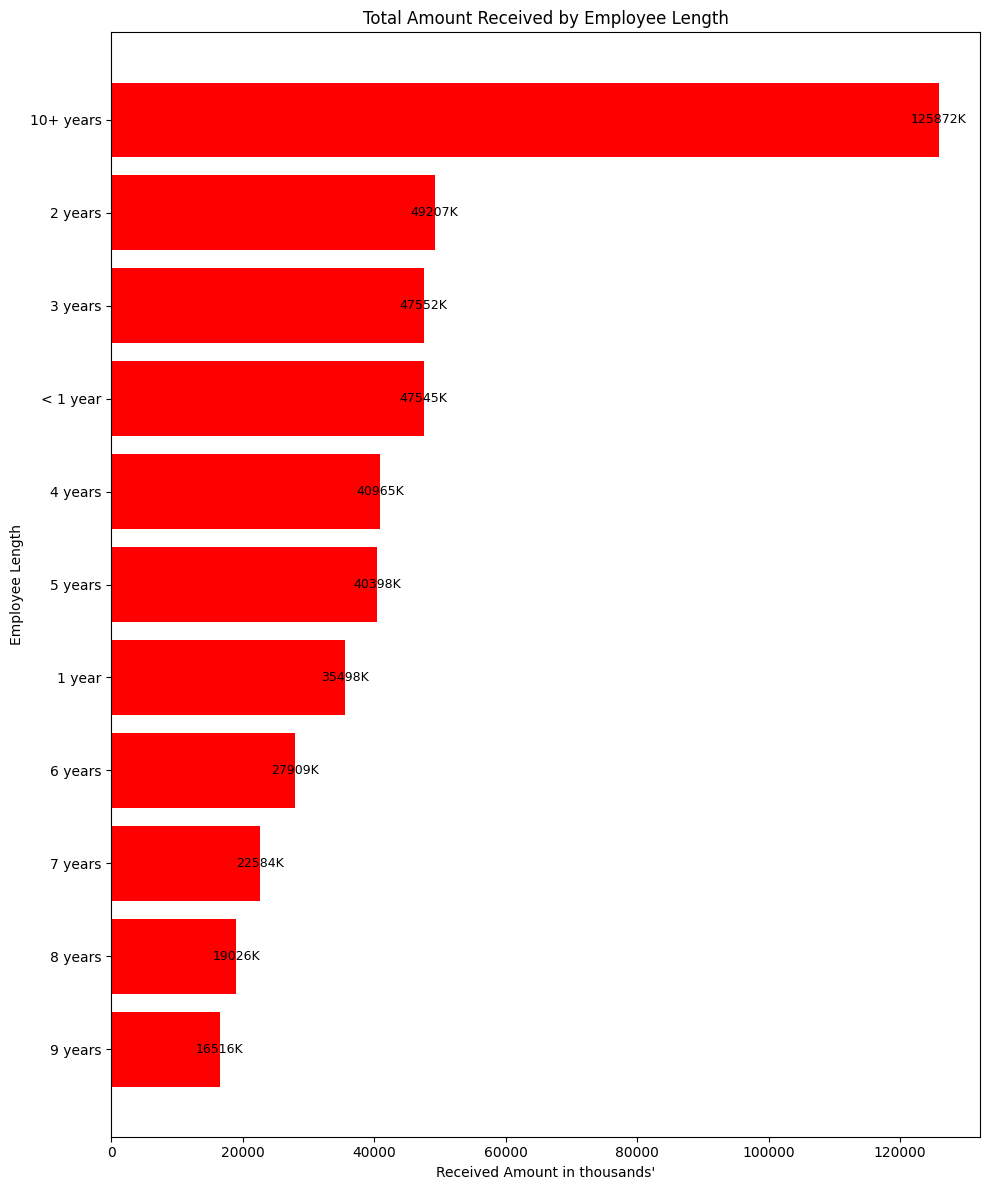

In [32]:
emp_received= df.groupby('emp_length')['total_payment'].sum().sort_values(ascending=True)/1000


plt.figure(figsize=(10,12))
barh=plt.barh(emp_received.index,emp_received.values,color='red')

for bar in barh:
    width=bar.get_width()
    plt.text(width+5,bar.get_y()+bar.get_height()/2,
             f"{width:0.0f}K",va='center',ha='center',fontsize=9)
    

plt.title('Total Amount Received by Employee Length')
plt.xlabel("Received Amount in thousands'")
plt.ylabel('Employee Length')
plt.tight_layout()
plt.show()

### Loan Purpose BY Total Funded Amount

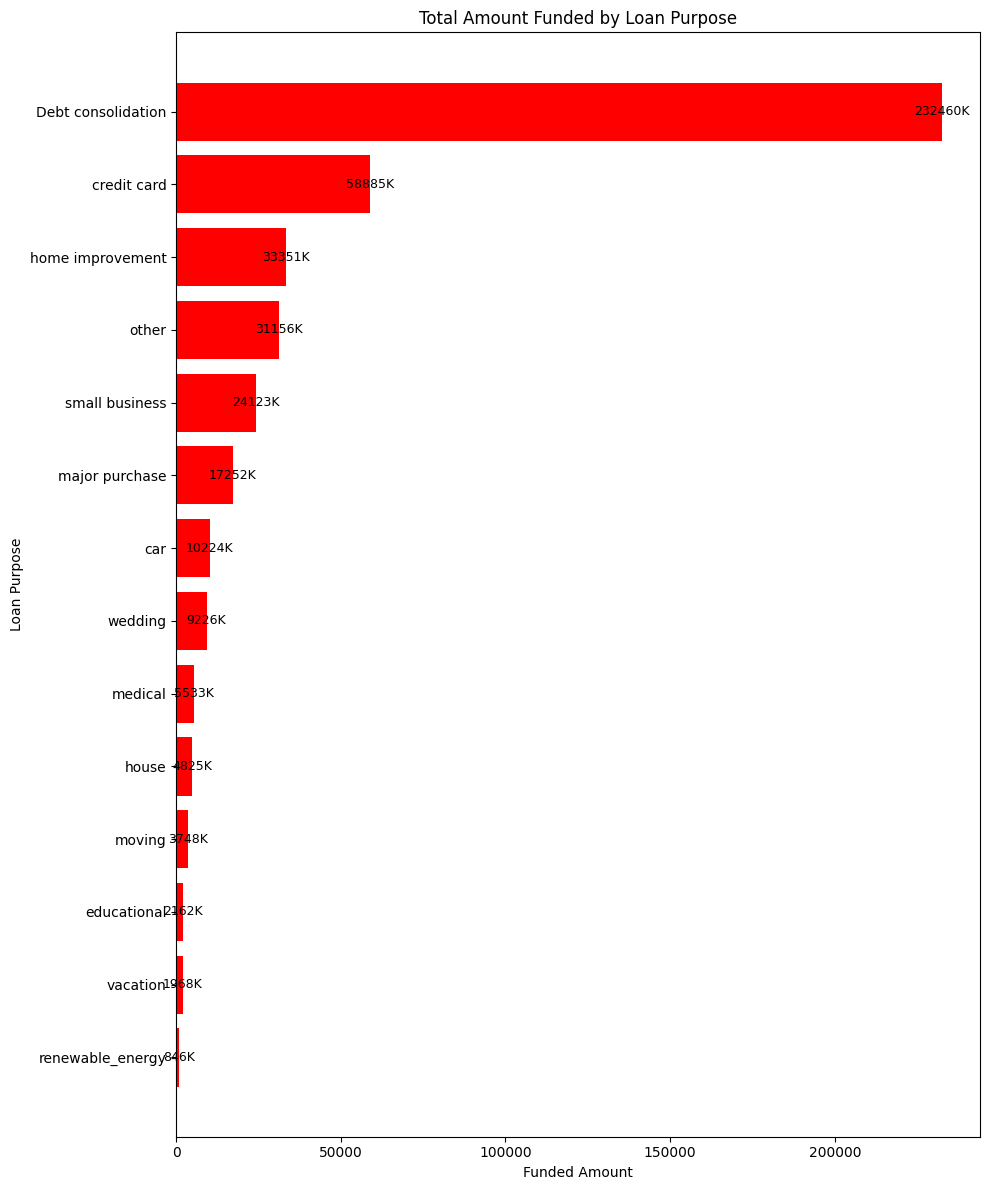

In [33]:
loan_purpose= df.groupby('purpose')['loan_amount'].sum().sort_values(ascending=True)/1000


plt.figure(figsize=(10,12))
barh=plt.barh(loan_purpose.index,loan_purpose.values,color='red')

for bar in barh:
    width=bar.get_width()
    plt.text(width+5,bar.get_y()+bar.get_height()/2,
             f"{width:0.0f}K",va='center',ha='center',fontsize=9)
    

plt.title('Total Amount Funded by Loan Purpose')
plt.xlabel("Funded Amount")
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()

### Home Ownership by Total funded Amount

In [ ]:
home_funding = (
    df.groupby('home_ownership')['loan_amount']
      .sum()
      .reset_index()
)

home_funding['loan_amount_million'] = (
    home_funding['loan_amount'] / 1000000
)

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_million',
    color='loan_amount_million',
    color_continuous_scale='Blues',
    title='Loan Amount Funded by Home Ownership'
)

fig.show()

### Home Ownership by Total Recieved Amount

In [ ]:
home_amount_recieved= (
    df.groupby('home_ownership')['total_payment']
      .sum()
      .reset_index()
)

home_amount_recieved['total_payment_million'] = (
    home_amount_recieved['total_payment'] / 1000000
)

fig = px.treemap(
    home_amount_recieved,
    path=['home_ownership'],
    values='total_payment_million',
    color='total_payment_million',
    color_continuous_scale='Blues',
    title='Loan Amount Recieved by Home Ownership'
)

fig.show()

: 

### Home Ownership by Total Number of application

In [ ]:
number_of_application= (
    df.groupby('home_ownership')['id']
      .count()
      .reset_index()
)

fig = px.treemap(
    number_of_application,
    path=['home_ownership'],
    values='total_payment_million',
    color='total_payment_million',
    color_continuous_scale='Blues',
    title='Number of applications0 by Home Ownership'
)

fig.show()

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='object')